

---


INDEPENDENT COMPONENT ANALYSIS

---



CASE STUDY 1:- MIXED SIGNALS


---



STEP 1: Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import FastICA

STEP 2: Generating Synthetic Mixed Signals

In [2]:
def generate_signals():
  np.random.seed(0)
  time = np.linspace(0,10,1000)
  s1 = np.sin(2* time)
  s2 = np.sign(np.sin(3*time))
  S = np.c_[s1,s2]
  S /= S.std(axis=0)

  #Mixing Matrix
  A = np.array([[1,0.5],[0.5,1]])
  X = S @ A.T
  return S,X

STEP 3: Apply ICA to recover Source Separation

In [3]:
def apply_ica(X):
  ica  = FastICA(n_components=2,random_state=0)
  S_ica = ica.fit_transform(X)
  return S_ica

STEP 4: PLOTTING

In [4]:
def plot_results(S,X,S_ica):
  fig,axes = plt.subplots(3,1,figsize=(10,8))

  axes[0].plot(S)
  axes[0].set_title("Original Source Signals")

  axes[1].plot(X)
  axes[1].set_title("Mixed Source Signals")

  axes[2].plot(S_ica)
  axes[2].set_title("Separated Source Signals")

  plt.tight_layout()
  plt.show()

STEP 5: MAIN PROGRAM

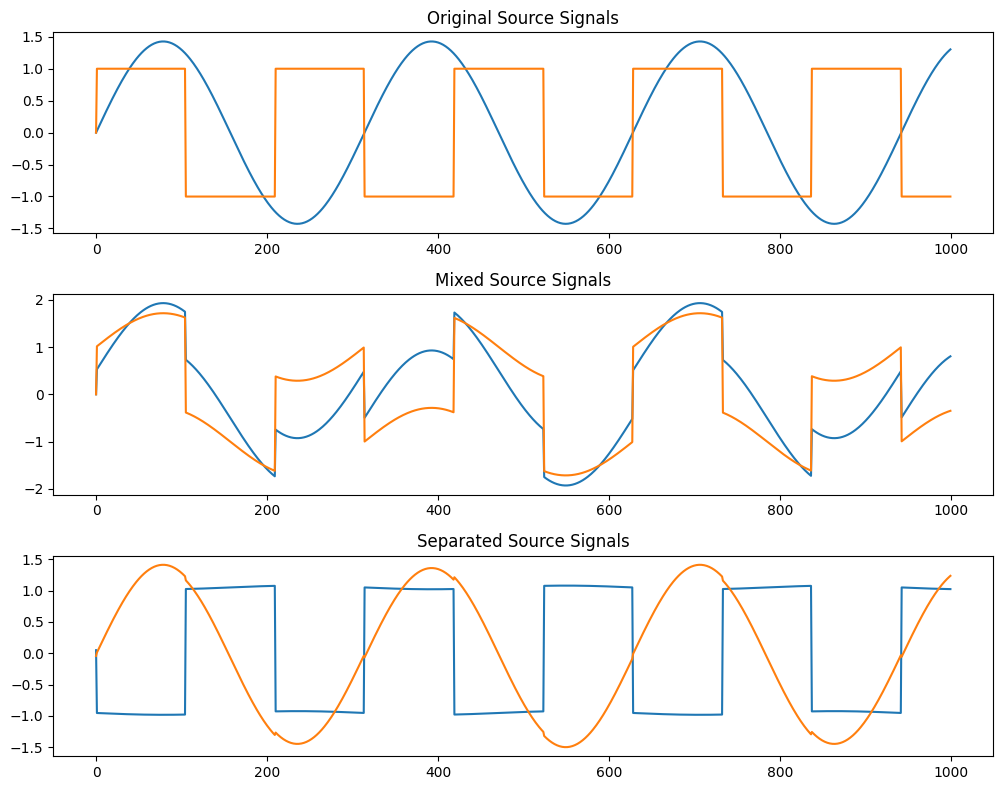

In [5]:
S,X = generate_signals()
S_ica = apply_ica(S)
plot_results(S,X,S_ica)

CASE STUDY 2:- Images Data


---





STEP 1 : Import Libraries

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import FastICA
from skimage import data,color,transform

In [7]:
def normalize(img):
  return (img - img.min())/(img.max()-img.min())

STEP 2: Load ready-made data

In [8]:
def load_sample_images(size=(256,256)):
  img1 = data.camera()
  img2 = data.coins()

  img1 = transform.resize(img1,size,anti_aliasing=True)
  img2 = transform.resize(img2,size,anti_aliasing=True)

  img1 = normalize(img1)
  img2 = normalize(img2)

  return img1,img2

STEP 3: Mixing Image

In [9]:
def mix_images(img1,img2):
  s1 = img1.flatten()
  s2 = img2.flatten()

  S = np.c_[s1,s2]

  S /= S.std(axis=0)

  A = np.array([[1,0.6],[0.4,1]])

  X = S @ A.T
  return S,X,img1.shape

In [10]:
def separate_image(X):
  ica = FastICA(n_components=2,random_state=0)
  S_ica = ica.fit_transform(X)
  return S_ica

In [11]:
def reshape_img(S,X,S_ica,shape):
  orig1 = normalize(S[:,0].reshape(shape))
  orig2 = normalize(S[:,1].reshape(shape))

  mix1 = normalize(X[:,0].reshape(shape))
  mix2 = normalize(X[:,1].reshape(shape))

  sep1 = normalize(S_ica[:,0].reshape(shape))
  sep2 = normalize(S_ica[:,1].reshape(shape))

  return orig1,orig2,mix1,mix2,sep1,sep2

In [15]:
def plot_results(orig1,orig2,mix1,mix2,sep1,sep2):
  fig,axes = plt.subplots(2,3,figsize=(12,8))

  images = [orig1,orig2,mix1,mix2,sep1,sep2]
  titles=[
      "Original Images 1",
      "Original Iamges 2",
      "Mixed Images 1",
      "Mixed images 2",
      "separated Iamges 1",
      "Separated Inages 2"
  ]

  for ax,img,title in zip(axes.flatten(),images,titles):
    ax.imshow(img,cmap="gray")
    ax.set_title(title)
    ax.axis("off")

  plt.tight_layout()
  plt.show()

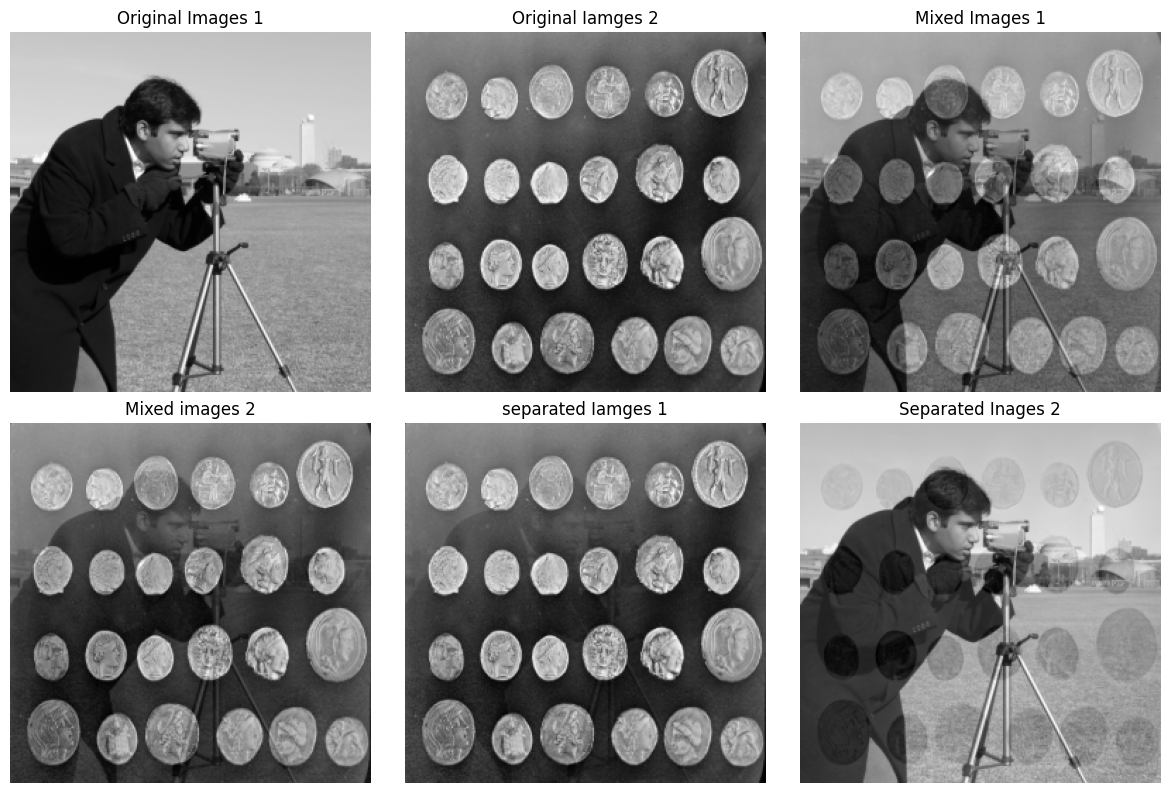

In [16]:
img1,img2 = load_sample_images()
S,X,shape = mix_images(img1,img2)
S_ica = separate_image(X)
orig1,orig2,mix1,mix2,sep1,sep2 = reshape_img(S,X,S_ica,shape)
plot_results(orig1,orig2,mix1,mix2,sep1,sep2)